In [1]:
!nvcc --version
!pip install cupy-cuda11x

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Thu_Nov_18_09:45:30_PST_2021
Cuda compilation tools, release 11.5, V11.5.119
Build cuda_11.5.r11.5/compiler.30672275_0
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import cupy as cp
import time

/opt/tljh/user/lib/python3.12/site-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda11x, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [3]:
def fun(nz, nx):
    fpeak = 30.0  # Częstotliwość źródła
    dt = 0.002  # Krok czasowy
    et = 0.5  # Czas symulacji
    ds = 0.02  # Odstęp w siatce
     
    # Materiały: powietrze i ziemia
    v_air = 343
    v_ground = 1000
     
    # Model z ostrymi kątami
    okop = np.zeros((nz, nx), dtype=bool)
    #okop[2:4, 10:15] = True
    #okop[4:10, 14:16] = True
    #okop[8:10, 15:20] = True
     
    okop[200:300, 100:250] = True
    okop[200:400, 250:350] = True
    okop[300:400, 270:500] = True
     
    V = np.full((nz, nx), v_ground)
    V[okop] = v_air
    
    vec_start_time = time.time() #==============================================================================================
    #wariant wektorowy
     
    et=0.1
     
    #trzeba znalezc vmax do warunku stabilnosci  
    vmax = 1000
     
    #dtr - realny krok probkowania ktory jest dzielnikiem dt
    dtr = min(dt, ds / (2.0 * vmax))
     
    #inicjalizacja paska postepu
    niter = int(et/dtr+1)
     
    kk = 1 # ilosc dtr na jedna dt
    kkk = 0 # ilosc dt
    k = 1   # ilosc dtr
     
    #macierze dla pól cisnienia w czasie t+1, t i t-1
    p = np.zeros((nz, nx))
    pm = np.zeros((nz, nx))
    pp = np.zeros((nz, nx))
     
    dtr_ds = dtr / ds
     
    fig = plt.figure("Test")
    ims = []
     
    #max cisnienie w punkcie pomiaru
    max_val=0
     
    while True:
        k += 1
        kk += 1
        t = k * dtr
     
        # Przeliczenie "po sąsiedzku"
        pp[1:-1, 1:-1] = (
            2.0 * p[1:-1, 1:-1]
            - pm[1:-1, 1:-1]
            + ((dtr * dtr) / (ds * ds))
            * V[1:-1, 1:-1]
            * V[1:-1, 1:-1]
            * (
                p[2:, 1:-1]
                + p[:-2, 1:-1]
                + p[1:-1, 2:]
                + p[1:-1, :-2]
                - 4.0 * p[1:-1, 1:-1]
            )
        )
     
        # Dodanie Rickera
        s = math.exp(-(((math.pi * fpeak * (t - (1.0 / fpeak))) ** 2))) * (
            1.0 - 2.0 * ((math.pi * fpeak * (t - (1.0 / fpeak))) ** 2)
        )
        pp[250, 150] += s
     
        # Warunki brzegowe
        # Lewa granica
        pp[:, 0] = (
            p[:, 0]
            + p[:, 1]
            - pm[:, 1]
            + V[:, 0] * dtr_ds * (p[:, 1] - p[:, 0] - (pm[:, 2] - pm[:, 1]))
        )
        # Prawa granica
        pp[:, -1] = (
            p[:, -1]
            + p[:, -2]
            - pm[:, -2]
            + V[:, -1] * dtr_ds * (p[:, -2] - p[:, -1] - (pm[:, -3] - pm[:, -2]))
        )
        # Górna granica
        pp[0, :] = (
            p[0, :]
            + p[1, :]
            - pm[1, :]
            + V[0, :] * dtr_ds * (p[1, :] - p[0, :] - (pm[2, :] - pm[1, :]))
        )
        # Dolna granica
        pp[-1, :] = (
            p[-1, :]
            + p[-2, :]
            - pm[-2, :]
            + V[-1, :] * dtr_ds * (p[-2, :] - p[-1, :] - (pm[-3, :] - pm[-2, :]))
        )
     
        # Krok do przodu
        pm[:] = p[:]
        p[:] = pp[:]
     
        #ciśnienie w punkcie pomiaru
        if max_val<pp[350,450]:
            max_val=pp[350,450]
       
        # Dodanie klatki co 0.02 sekundy
        if kk * dtr + dtr / 10.0 >= dt:
            kk = 0
            kkk += 1
            im = plt.imshow(
                p,
                cmap="hot"
            )
            ims.append([im])
     
            if kkk * dt > et:
                break
     
    # Utworzenie animacji
    ani = animation.ArtistAnimation(fig, ims, interval=10, blit=True, repeat_delay=1000)
    plt.close()
     
    # Wyświetlenie animacji
    HTML(ani.to_html5_video())
    
    vec_end_time = time.time() #=========================================================================================================================================
    gpu_start_time = time.time()
     
    # zmienne na GPU
    p = cp.zeros((nz, nx))
    pm = cp.zeros((nz, nx))
    pp = cp.zeros((nz, nx))
    V_gpu = cp.asarray(V)  # V było na CPU (NumPy), trzeba przenieść na GPU
     
    # pozostałe parametry
    vmax = 1000
    dtr = min(dt, ds / (2.0 * vmax))
    niter = int(et / dtr + 1)
    kk = 1
    kkk = 0
    k = 1
    dtr_ds = dtr / ds
     
    fig = plt.figure("Test")
    ims = []
     
    max_val = 0
     
    while True:
        k += 1
        kk += 1
        t = k * dtr
     
        pp[1:-1, 1:-1] = (
            2.0 * p[1:-1, 1:-1]
            - pm[1:-1, 1:-1]
            + ((dtr * dtr) / (ds * ds))
            * V_gpu[1:-1, 1:-1] ** 2
            * (
                p[2:, 1:-1]
                + p[:-2, 1:-1]
                + p[1:-1, 2:]
                + p[1:-1, :-2]
                - 4.0 * p[1:-1, 1:-1]
            )
        )
     
        # Źródło Ricker wavelet
        arg = cp.pi * fpeak * (t - (1.0 / fpeak))
        s = cp.exp(-(arg ** 2)) * (1.0 - 2.0 * (arg ** 2))
        pp[250, 150] += s
     
        # Warunki brzegowe
        pp[:, 0] = (
            p[:, 0]
            + p[:, 1]
            - pm[:, 1]
            + V_gpu[:, 0] * dtr_ds * (p[:, 1] - p[:, 0] - (pm[:, 2] - pm[:, 1]))
        )
        pp[:, -1] = (
            p[:, -1]
            + p[:, -2]
            - pm[:, -2]
            + V_gpu[:, -1] * dtr_ds * (p[:, -2] - p[:, -1] - (pm[:, -3] - pm[:, -2]))
        )
        pp[0, :] = (
            p[0, :]
            + p[1, :]
            - pm[1, :]
            + V_gpu[0, :] * dtr_ds * (p[1, :] - p[0, :] - (pm[2, :] - pm[1, :]))
        )
        pp[-1, :] = (
            p[-1, :]
            + p[-2, :]
            - pm[-2, :]
            + V_gpu[-1, :] * dtr_ds * (p[-2, :] - p[-1, :] - (pm[-3, :] - pm[-2, :]))
        )
     
        # Krok w przód
        pm[:] = p[:]
        p[:] = pp[:]
     
        if max_val < pp[350, 450]:
            max_val = pp[350, 450]
     
        if kk * dtr + dtr / 10.0 >= dt:
            kk = 0
            kkk += 1
            im = plt.imshow(cp.asnumpy(p), cmap="hot")  # przekopiowanie z GPU do CPU
            ims.append([im])
     
            if kkk * dt > et:
                break
     
    # Animacja
    ani = animation.ArtistAnimation(fig, ims, interval=10, blit=True, repeat_delay=1000)
    plt.close()
    HTML(ani.to_html5_video())
    gpu_end_time = time.time()

    print("Wektorowo:")
    print(vec_end_time - vec_start_time)
    print("GPU:")
    print(gpu_end_time - gpu_start_time)


In [4]:
for i in range(600, 1201, 200):
    nz, nx = i, i
    print("="*50)
    print(f"Rozmiar modelu: {nz} x {nx}")
    print("-"*50)
    
    fun(nz, nx)

Rozmiar modelu: 600 x 600
--------------------------------------------------
Wektorowo:
145.32395386695862
GPU:
19.032241582870483

Rozmiar modelu: 800 x 800
--------------------------------------------------
Wektorowo:
287.9076681137085
GPU:
21.841203212738037

Rozmiar modelu: 1000 x 1000
--------------------------------------------------
Wektorowo:
256.42715764045715
GPU:
21.406094551086426

Rozmiar modelu: 1200 x 1200
--------------------------------------------------
Wektorowo:
321.19897508621216
GPU:
28.301488637924194



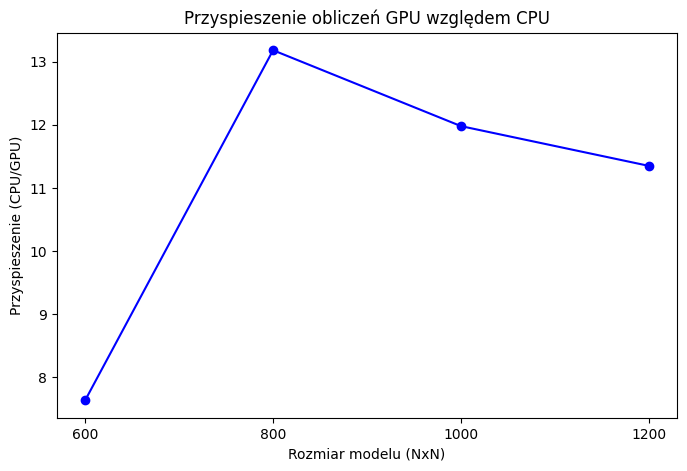

In [5]:
sizes = [600, 800, 1000, 1200]

speedup = [145.32395386695862/19.032241582870483, 287.9076681137085/21.841203212738037, 256.42715764045715/21.406094551086426, 321.19897508621216/28.301488637924194]

plt.figure(figsize=(8,5))
plt.plot(sizes, speedup, marker='o', linestyle='-', color='blue')
plt.title("Przyspieszenie obliczeń GPU względem CPU")
plt.xlabel("Rozmiar modelu (NxN)")
plt.ylabel("Przyspieszenie (CPU/GPU)")
plt.xticks(sizes)
plt.show()